# Model Training and Evaluation

This notebook demonstrates the final modeling pipeline for the consumer behavior classification project.

The preprocessing, model training, and evaluation logic are implemented in Python modules, while this notebook is used to show the final workflow and results in a compact form.

In [41]:
import pandas as pd

from consumer_behavior_project.preprocessing import load_data, preprocess_data
from consumer_behavior_project.model import (
    train_logistic_regression,
    train_svm,
    train_random_forest,
    train_logistic_regression_smote,
    evaluate_model,
    build_results_table,
)
from consumer_behavior_project.evaluation import (
    plot_confusion_matrix,
    get_feature_importance_dataframe,
    plot_feature_importance,
    plot_model_comparison,
    plot_multiclass_roc,
    plot_multiclass_precision_recall,
)

## Load and preprocess data

In [42]:
df = load_data("../data/online vs store shopping dataset.csv")
X_train, X_test, y_train, y_test, label_encoder = preprocess_data(df)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (9431, 28)
X_test: (2358, 28)


## Train and evaluate models

In [43]:
log_model = train_logistic_regression(X_train, y_train)
log_results = evaluate_model(log_model, X_test, y_test)

svm_model = train_svm(X_train, y_train)
svm_results = evaluate_model(svm_model, X_test, y_test)

rf_model = train_random_forest(X_train, y_train)
rf_results = evaluate_model(rf_model, X_test, y_test)

log_smote_model, _, _ = train_logistic_regression_smote(X_train, y_train)
smote_results = evaluate_model(log_smote_model, X_test, y_test)

## Compare model performance

In [44]:
results = build_results_table(
    log_results["accuracy"], log_results["f1_score"],
    smote_results["accuracy"], smote_results["f1_score"],
    svm_results["accuracy"], svm_results["f1_score"],
    rf_results["accuracy"], rf_results["f1_score"],
)

results

,Model,Accuracy,F1 Score
1,Logistic Regression (SMOTE),0.966497,0.971990
0,Logistic Regression,0.957167,0.965353
2,SVM,0.932570,0.942243
3,Random Forest,0.947413,0.931350


Saved plot: outputs/plots\model_comparison.png


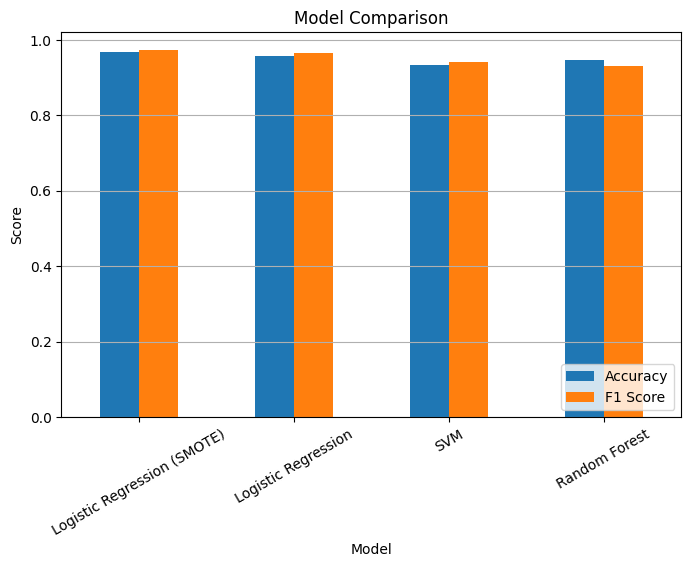

In [45]:
plot_model_comparison(results)

## Selected evaluation plots

Saved plot: outputs/plots\confusion_matrix_logistic_regression.png


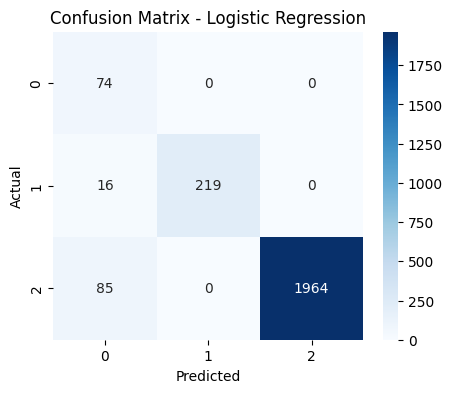

Saved plot: outputs/plots\confusion_matrix_logistic_regression_(smote).png


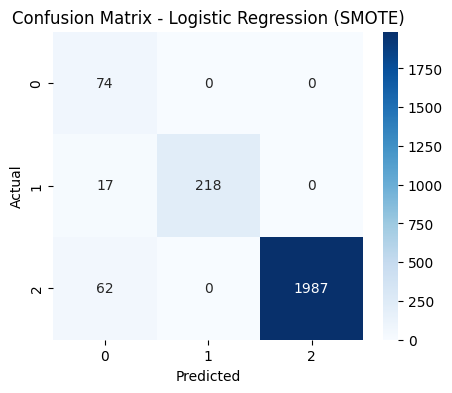

In [46]:
plot_confusion_matrix(y_test, log_results["y_pred"], "Logistic Regression")
plot_confusion_matrix(y_test, smote_results["y_pred"], "Logistic Regression (SMOTE)")

Saved plot: outputs/plots\feature_importance_random_forest.png


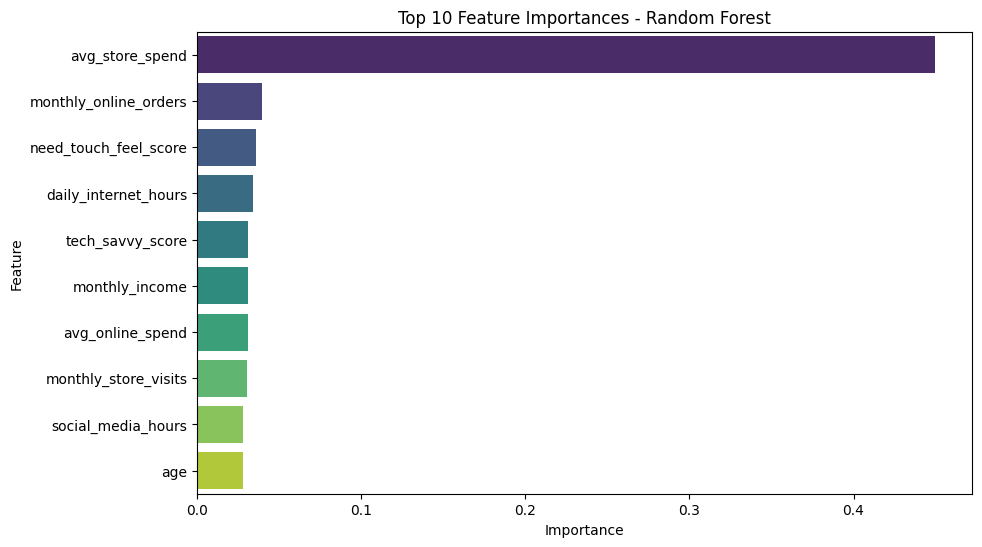

In [47]:
feature_importance = get_feature_importance_dataframe(rf_model, X_train.columns)
plot_feature_importance(feature_importance)

Saved plot: outputs/plots\roc_logistic_regression.png


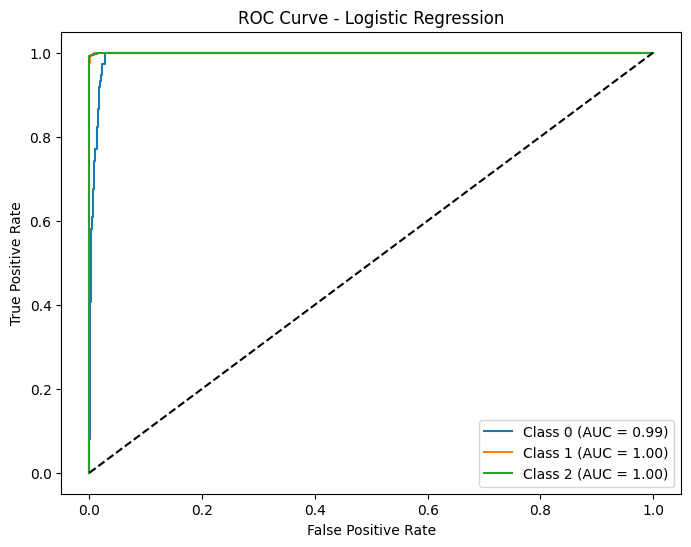

Saved plot: outputs/plots\pr_logistic_regression.png


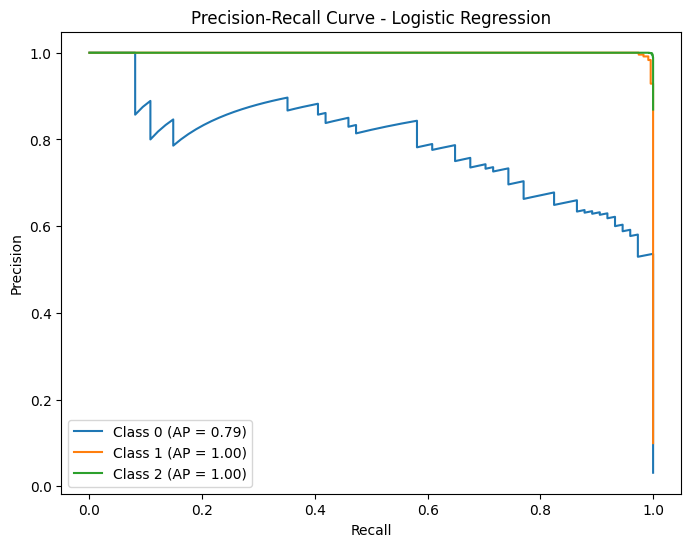

In [50]:
plot_multiclass_roc(log_model, X_test, y_test, "Logistic Regression")
plot_multiclass_precision_recall(log_model, X_test, y_test, "Logistic Regression")

## Conclusion

Among the tested models, Logistic Regression with SMOTE achieved the best overall performance.

This shows that handling class imbalance was important for improving the classification of minority classes.